# Hybrid Table Extraction: UniTable (Apple Silicon) + Gemini Refinement

3-way comparison on PubTabNet examples:
1. **UniTable only** — Structure + OCR locally on MPS
2. **Gemini only** — Vision LLM extracts HTML directly from image
3. **Hybrid** — UniTable structure + Gemini refines cell text

Scored with **TEDS** (Tree Edit Distance-based Similarity).

In [38]:
import json
import re
import sys
import base64
import io
import time
from pathlib import Path

import pandas as pd
from PIL import Image
from IPython.display import display, HTML

# Project paths
project_root = Path.cwd().parent
huma_root = project_root / "Huma-Huma"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(huma_root) not in sys.path:
    sys.path.insert(0, str(huma_root))
# UniTable needs its repo on path
unitable_repo = huma_root / "unitable"
if str(unitable_repo) not in sys.path:
    sys.path.insert(0, str(unitable_repo))

# TEDS metric
teds_src = project_root / "pubtabnet" / "src"
if str(teds_src) not in sys.path:
    sys.path.insert(0, str(teds_src))

from metric import TEDS

teds_scorer = TEDS(structure_only=False)
teds_structure = TEDS(structure_only=True)
print("TEDS scorer ready")

TEDS scorer ready


## Load PubTabNet ground truth

In [39]:
def format_html_clean(img):
    """Build GT HTML from PubTabNet annotation without prettify whitespace."""
    html_string = '<html><body><table>%s</table></body></html>' % ''.join(img['html']['structure']['tokens'])
    cell_nodes = list(re.finditer(r'(<td[^<>]*>)(</td>)', html_string))
    cells = [''.join(c['tokens']) for c in img['html']['cells']]
    offset = 0
    for n, cell in zip(cell_nodes, cells):
        html_string = html_string[:n.end(1) + offset] + cell + html_string[n.start(2) + offset:]
        offset += len(cell)
    return html_string

gt_path = project_root / "pubtabnet" / "examples" / "PubTabNet_Examples.jsonl"
examples = []
with open(gt_path) as f:
    for line in f:
        examples.append(json.loads(line))

img_dir = project_root / "pubtabnet" / "examples"
gt_data = []
for ex in examples:
    fname = ex["filename"]
    img_path = img_dir / fname
    if img_path.exists():
        gt_data.append({"filename": fname, "image_path": img_path, "gt_html": format_html_clean(ex)})

# Set N for how many to evaluate (all 20, or fewer for quick test)
N = 7
gt_data = gt_data[:N]
print(f"Evaluating {len(gt_data)} images")

Evaluating 7 images


## Load UniTable (local MPS)

In [40]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "unitable_extractor",
    str(huma_root / "table_extraction" / "unitable.py")
)
unitable_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unitable_mod)

extractor = unitable_mod.UniTableExtractor()  # auto-detects MPS
print(f"UniTable device: {extractor.device}")

Loading UniTable models...
  ✓ Structure model loaded
  ✓ Bbox model loaded
  ✓ Content model loaded
UniTable ready for inference!
UniTable device: mps


## Method 1: UniTable only

In [41]:
unitable_results = {}

for item in gt_data:
    fname = item["filename"]
    print(f"  UniTable: {fname} ... ", end="", flush=True)
    image = Image.open(item["image_path"]).convert("RGB")
    t0 = time.time()
    try:
        html_out = extractor.extract_html(image)
        elapsed = time.time() - t0
        unitable_results[fname] = html_out
        print(f"{elapsed:.1f}s")
    except Exception as e:
        print(f"FAILED: {e}")
        unitable_results[fname] = ""

print(f"\nUniTable: {sum(1 for v in unitable_results.values() if v)}/{len(gt_data)} extracted")

  UniTable: PMC4840965_004_00.png ... 81.4s
  UniTable: PMC4517499_004_00.png ... 22.2s
  UniTable: PMC4776821_005_00.png ... 17.5s
  UniTable: PMC1626454_002_00.png ... 134.6s
  UniTable: PMC2838834_005_00.png ... 292.3s
  UniTable: PMC5897438_004_00.png ... 26.3s
  UniTable: PMC3907710_006_00.png ... 14.5s

UniTable: 7/7 extracted


## Method 2: Gemini Vision (direct HTML)

In [42]:
from shared.client import client, DEFAULT_MODEL

GEMINI_TABLE_PROMPT = """Extract the table from this image as an HTML <table>.

Rules:
- Output ONLY the HTML table, nothing else
- Use <thead>/<tbody> tags
- Use colspan/rowspan for spanning cells
- Preserve all text exactly as shown (numbers, symbols, formatting)
- Use <b> for bold text, <i> for italic
- Wrap in <html><body>...</body></html>
"""


def gemini_extract_html(image: Image.Image) -> str:
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    img_bytes = buf.getvalue()

    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[
            {"inline_data": {"mime_type": "image/png", "data": base64.b64encode(img_bytes).decode()}},
            GEMINI_TABLE_PROMPT,
        ],
    )
    text = response.text.strip()
    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text


gemini_results = {}

for item in gt_data:
    fname = item["filename"]
    print(f"  Gemini: {fname} ... ", end="", flush=True)
    image = Image.open(item["image_path"]).convert("RGB")
    t0 = time.time()
    try:
        html_out = gemini_extract_html(image)
        elapsed = time.time() - t0
        gemini_results[fname] = html_out
        print(f"{elapsed:.1f}s")
    except Exception as e:
        print(f"FAILED: {e}")
        gemini_results[fname] = ""

print(f"\nGemini: {sum(1 for v in gemini_results.values() if v)}/{len(gt_data)} extracted")

  Gemini: PMC4840965_004_00.png ... 45.5s
  Gemini: PMC4517499_004_00.png ... 9.5s
  Gemini: PMC4776821_005_00.png ... 22.8s
  Gemini: PMC1626454_002_00.png ... 16.1s
  Gemini: PMC2838834_005_00.png ... 92.8s
  Gemini: PMC5897438_004_00.png ... 38.7s
  Gemini: PMC3907710_006_00.png ... 5.4s

Gemini: 7/7 extracted


## Method 3: Hybrid (UniTable structure + Gemini cell refinement)

In [43]:
HYBRID_REFINE_PROMPT = """I have an HTML table extracted by a model from the attached image.
The table STRUCTURE (rows, columns, spanning) is correct, but some cell text may have OCR errors.

Look at the image and fix ONLY the cell text content. Do NOT change:
- Table structure (rows, columns, colspan, rowspan)
- HTML tags or attributes
- The number of cells

Return the corrected HTML table. Output ONLY the HTML, nothing else.

Current HTML:
{html}
"""


def hybrid_extract(image: Image.Image, unitable_html: str) -> str:
    if not unitable_html:
        return ""
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    img_bytes = buf.getvalue()
    prompt = HYBRID_REFINE_PROMPT.format(html=unitable_html)

    response = client.models.generate_content(
        model=DEFAULT_MODEL,
        contents=[
            {"inline_data": {"mime_type": "image/png", "data": base64.b64encode(img_bytes).decode()}},
            prompt,
        ],
    )
    text = response.text.strip()
    text = re.sub(r'^```html\s*', '', text)
    text = re.sub(r'\s*```$', '', text)
    return text


hybrid_results = {}

for item in gt_data:
    fname = item["filename"]
    print(f"  Hybrid: {fname} ... ", end="", flush=True)
    image = Image.open(item["image_path"]).convert("RGB")
    t0 = time.time()
    try:
        html_out = hybrid_extract(image, unitable_results.get(fname, ""))
        elapsed = time.time() - t0
        hybrid_results[fname] = html_out
        print(f"{elapsed:.1f}s")
    except Exception as e:
        print(f"FAILED: {e}")
        hybrid_results[fname] = ""

print(f"\nHybrid: {sum(1 for v in hybrid_results.values() if v)}/{len(gt_data)} refined")

  Hybrid: PMC4840965_004_00.png ... 42.2s
  Hybrid: PMC4517499_004_00.png ... 12.4s
  Hybrid: PMC4776821_005_00.png ... 7.8s
  Hybrid: PMC1626454_002_00.png ... 36.4s
  Hybrid: PMC2838834_005_00.png ... 31.1s
  Hybrid: PMC5897438_004_00.png ... 55.5s
  Hybrid: PMC3907710_006_00.png ... 16.6s

Hybrid: 7/7 refined


## TEDS Evaluation

In [44]:
rows = []

for item in gt_data:
    fname = item["filename"]
    gt_html = item["gt_html"]
    row = {"filename": fname}

    for method, results in [("UniTable", unitable_results), ("Gemini", gemini_results), ("Hybrid", hybrid_results)]:
        pred = results.get(fname, "")
        teds_full = teds_scorer.evaluate(pred, gt_html) if pred else 0.0
        teds_struct = teds_structure.evaluate(pred, gt_html) if pred else 0.0
        row[f"{method} TEDS"] = round(teds_full, 3)
        row[f"{method} Struct"] = round(teds_struct, 3)

    rows.append(row)

df_scores = pd.DataFrame(rows)
display(df_scores)

# Aggregates
print("\n" + "=" * 60)
print("AGGREGATE TEDS SCORES")
print("=" * 60)
for method in ["UniTable", "Gemini", "Hybrid"]:
    teds_col = df_scores[f"{method} TEDS"]
    struct_col = df_scores[f"{method} Struct"]
    print(f"{method:12s} | TEDS: {teds_col.mean():.3f} (mean) | Structure: {struct_col.mean():.3f} (mean)")

,filename,UniTable TEDS,UniTable Struct,Gemini TEDS,Gemini Struct,Hybrid TEDS,Hybrid Struct
0,PMC4840965_004_00.png,0.952,1.0,0.928,0.966,0.964,1.0
1,PMC4517499_004_00.png,0.922,1.0,0.829,0.829,0.941,1.0
2,PMC4776821_005_00.png,0.952,1.0,0.992,1.000,0.964,1.0
3,PMC1626454_002_00.png,0.978,1.0,0.871,0.871,0.978,1.0
4,PMC2838834_005_00.png,0.947,1.0,0.801,0.801,0.992,1.0
5,PMC5897438_004_00.png,0.990,1.0,0.891,0.892,0.990,1.0
6,PMC3907710_006_00.png,0.857,1.0,0.677,0.677,0.949,1.0



AGGREGATE TEDS SCORES
UniTable     | TEDS: 0.943 (mean) | Structure: 1.000 (mean)
Gemini       | TEDS: 0.856 (mean) | Structure: 0.862 (mean)
Hybrid       | TEDS: 0.968 (mean) | Structure: 1.000 (mean)


## Visual comparison


PMC4840965_004_00.png


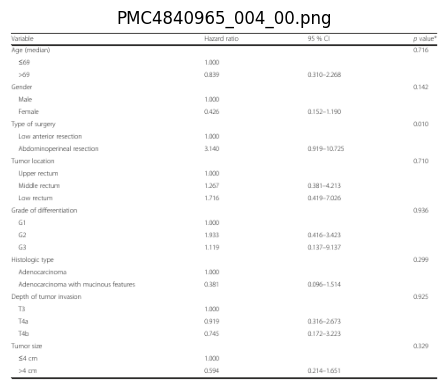

  UniTable    : TEDS = 0.952
  Gemini      : TEDS = 0.928
  Hybrid      : TEDS = 0.964

Ground Truth:


Variable,Hazard ratio,95 % CI,p value*
Age (median),,,0.716
≤69,1.000,,
>69,0.839,0.310–2.268,
Gender,,,0.142
Male,1.000,,
Female,0.426,0.152–1.190,
Type of surgery,,,0.010
Low anterior resection,1.000,,
Abdominoperineal resection,3.140,0.919–10.725,
Tumor location,,,0.710



Best (Hybrid, TEDS=0.964):


Variable,Hazard ratio,95 % CI,p value*
Age (median),,,0.716
≤69,1.000,,
>69,0.839,0.310-2.268,
Gender,,,0.142
Male,1.000,,
Female,0.426,0.152-1.190,
Type of surgery,,,0.010
Low anterior resection,1.000,,
Abdominoperineal resection,3.140,0.919-10.725,
Tumor location,,,0.710



PMC4517499_004_00.png


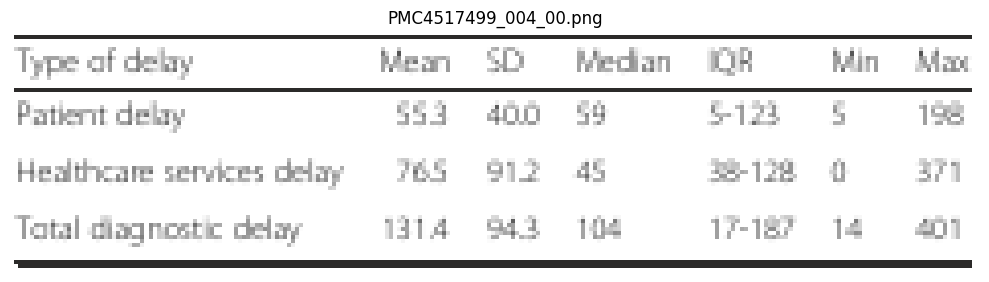

  UniTable    : TEDS = 0.922
  Gemini      : TEDS = 0.829
  Hybrid      : TEDS = 0.941

Ground Truth:


Type of delay,Mean,SD,Median,IQR,Min,Max
Patient delay,55.3,40.0,59,5-123,5,198
Healthcare services delay,76.5,91.2,45,38-128,0,371
Total diagnostic delay,131.4,94.3,104,17-187,14,401



Best (Hybrid, TEDS=0.941):


Type of delay,Mean,SD,Median,IQR,Min,Max
Patient delay,55.3,40.0,59,5-123,5,198
Healthcare services delay,76.5,91.2,45,38-128,0,371
Total diagnostic delay,131.4,94.3,104,17-187,14,401



PMC4776821_005_00.png


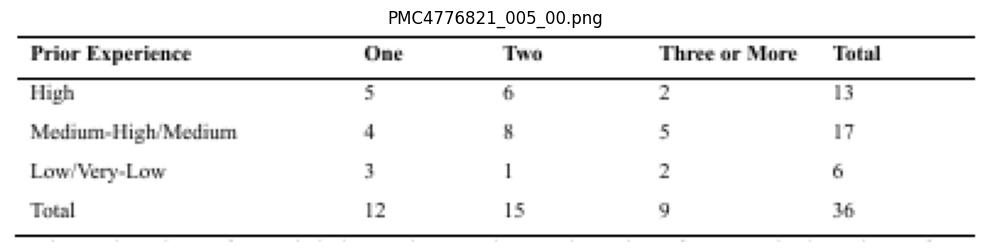

  UniTable    : TEDS = 0.952
  Gemini      : TEDS = 0.992
  Hybrid      : TEDS = 0.964

Ground Truth:


Prior Experience,One,Two,Three or More,Total
High,5,6,2,13
Medium-High/Medium,4,8,5,17
Low/Very-Low,3,1,2,6
Total,12,15,9,36



Best (Gemini, TEDS=0.992):


Prior Experience,One,Two,Three or More,Total
High,5,6,2,13
Medium-High/Medium,4,8,5,17
Low/Very-Low,3,1,2,6
Total,12,15,9,36


In [45]:
import matplotlib.pyplot as plt

for item in gt_data[:3]:
    fname = item["filename"]
    img = Image.open(item["image_path"])

    print(f"\n{'='*80}")
    print(f"{fname}")
    print(f"{'='*80}")

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # TEDS per method
    best_name, best_html, best_score = None, "", 0.0
    for method, results in [("UniTable", unitable_results), ("Gemini", gemini_results), ("Hybrid", hybrid_results)]:
        pred = results.get(fname, "")
        score = teds_scorer.evaluate(pred, item["gt_html"]) if pred else 0.0
        print(f"  {method:12s}: TEDS = {score:.3f}")
        if score > best_score:
            best_name, best_html, best_score = method, pred, score

    print("\nGround Truth:")
    display(HTML(item["gt_html"]))

    if best_html:
        print(f"\nBest ({best_name}, TEDS={best_score:.3f}):")
        display(HTML(best_html))